In [ ]:
import seaborn as sns
import pandas as pd

# Load the dataset
diamonds = sns.load_dataset("diamonds")

# Quick inspection
print("--- INFO ---")
diamonds.info()

print("\n--- DESCRIBE ---")
print(diamonds.describe())

print(diamonds.isnull().sum() / len(diamonds) * 100)


df=diamonds

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

--- DESCRIBE ---
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.

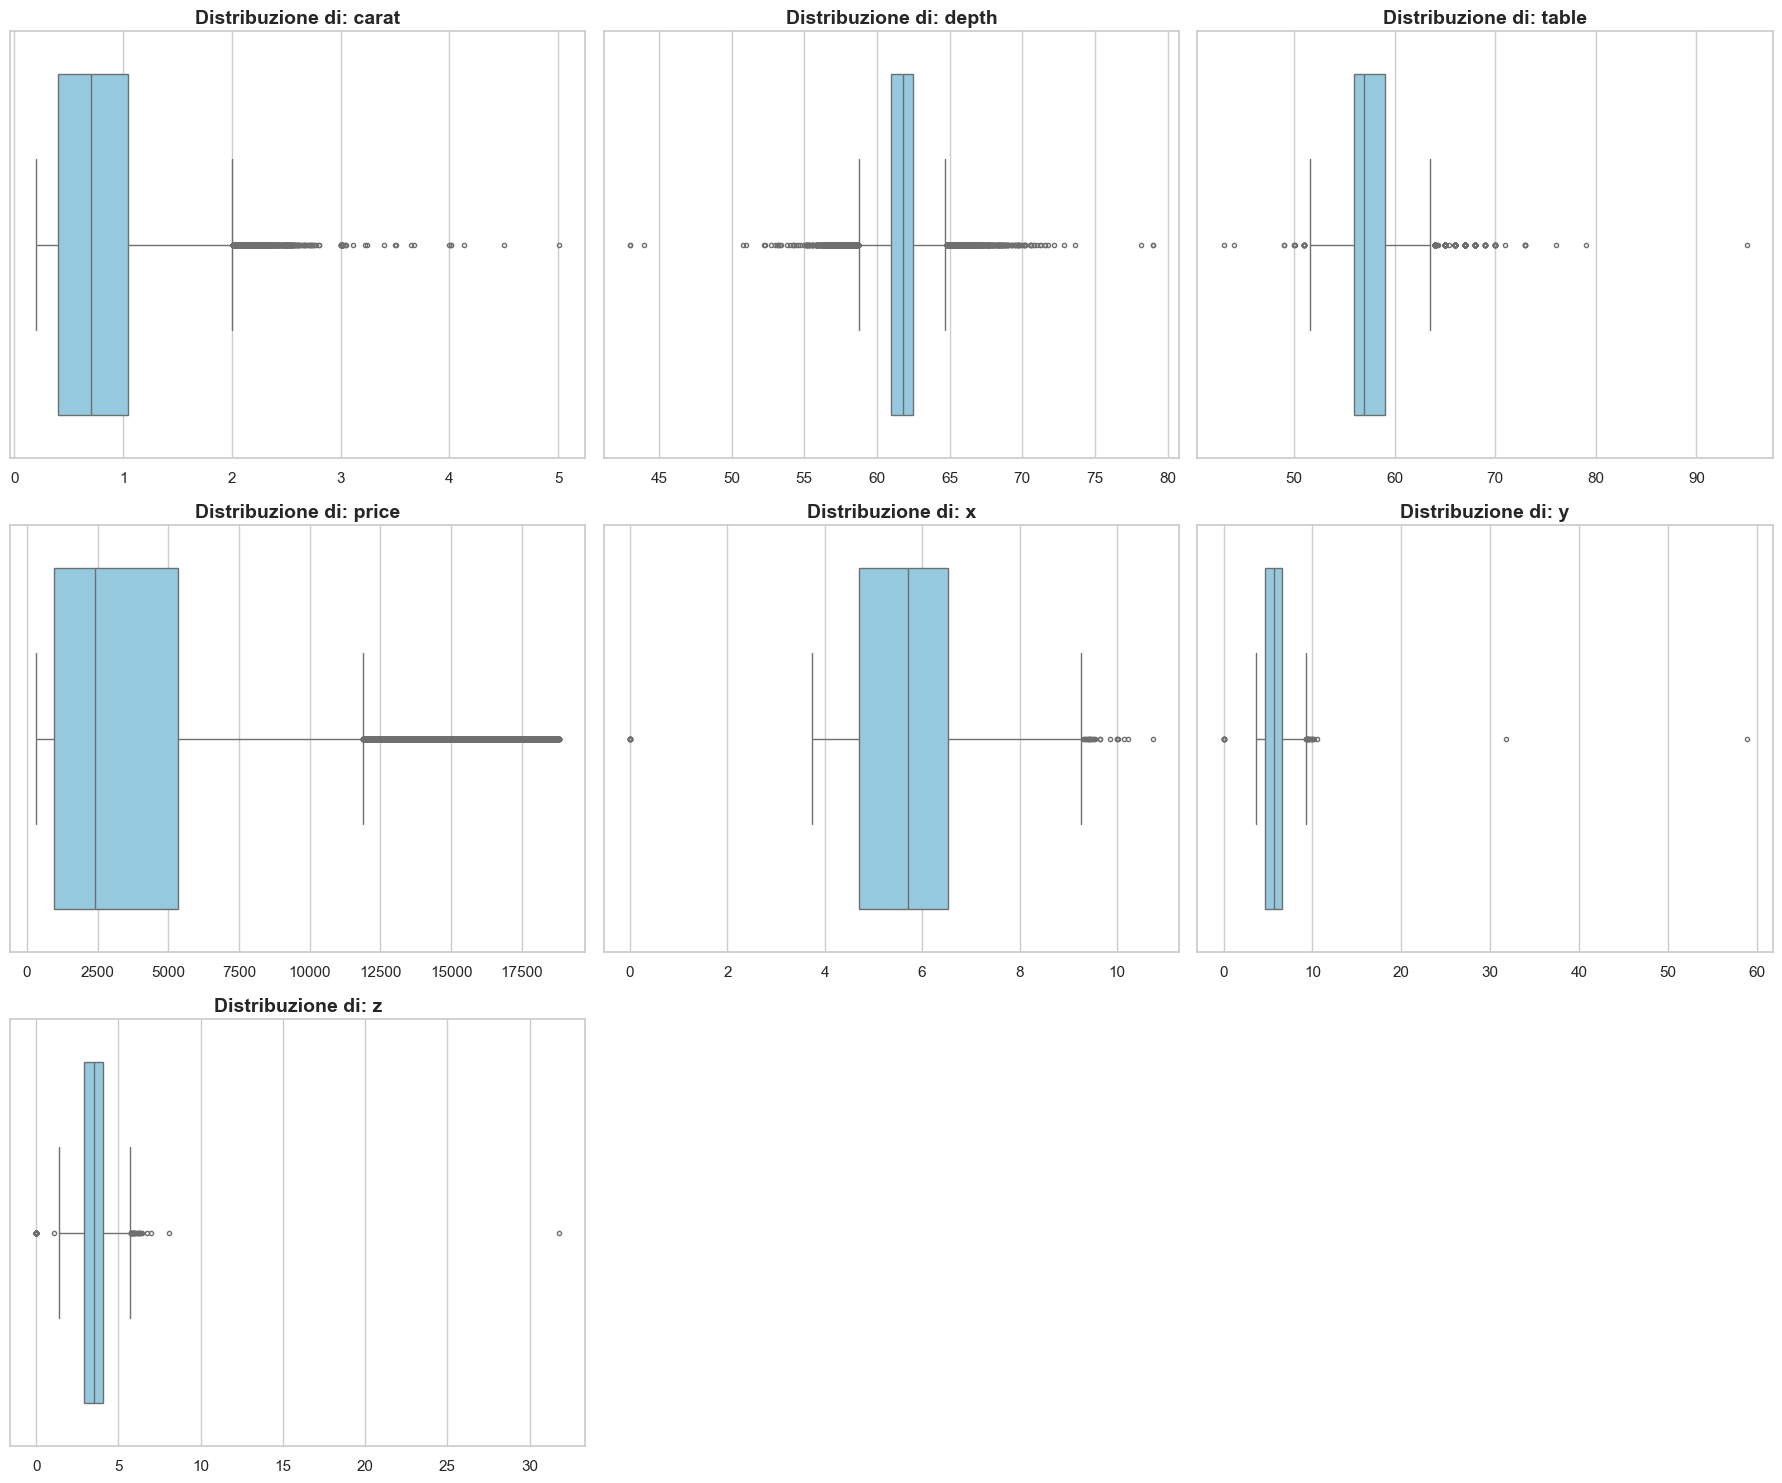

In [7]:
import matplotlib.pyplot as plt
# Impostiamo lo stile e la griglia

sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione

df = remove_outliers_zscore(df, ['carat', 'depth', 'table', 'price', 'x', 'y', 'z'])
#print(f"Righe rimosse con Z-Score: {len(df) - len(df)}")

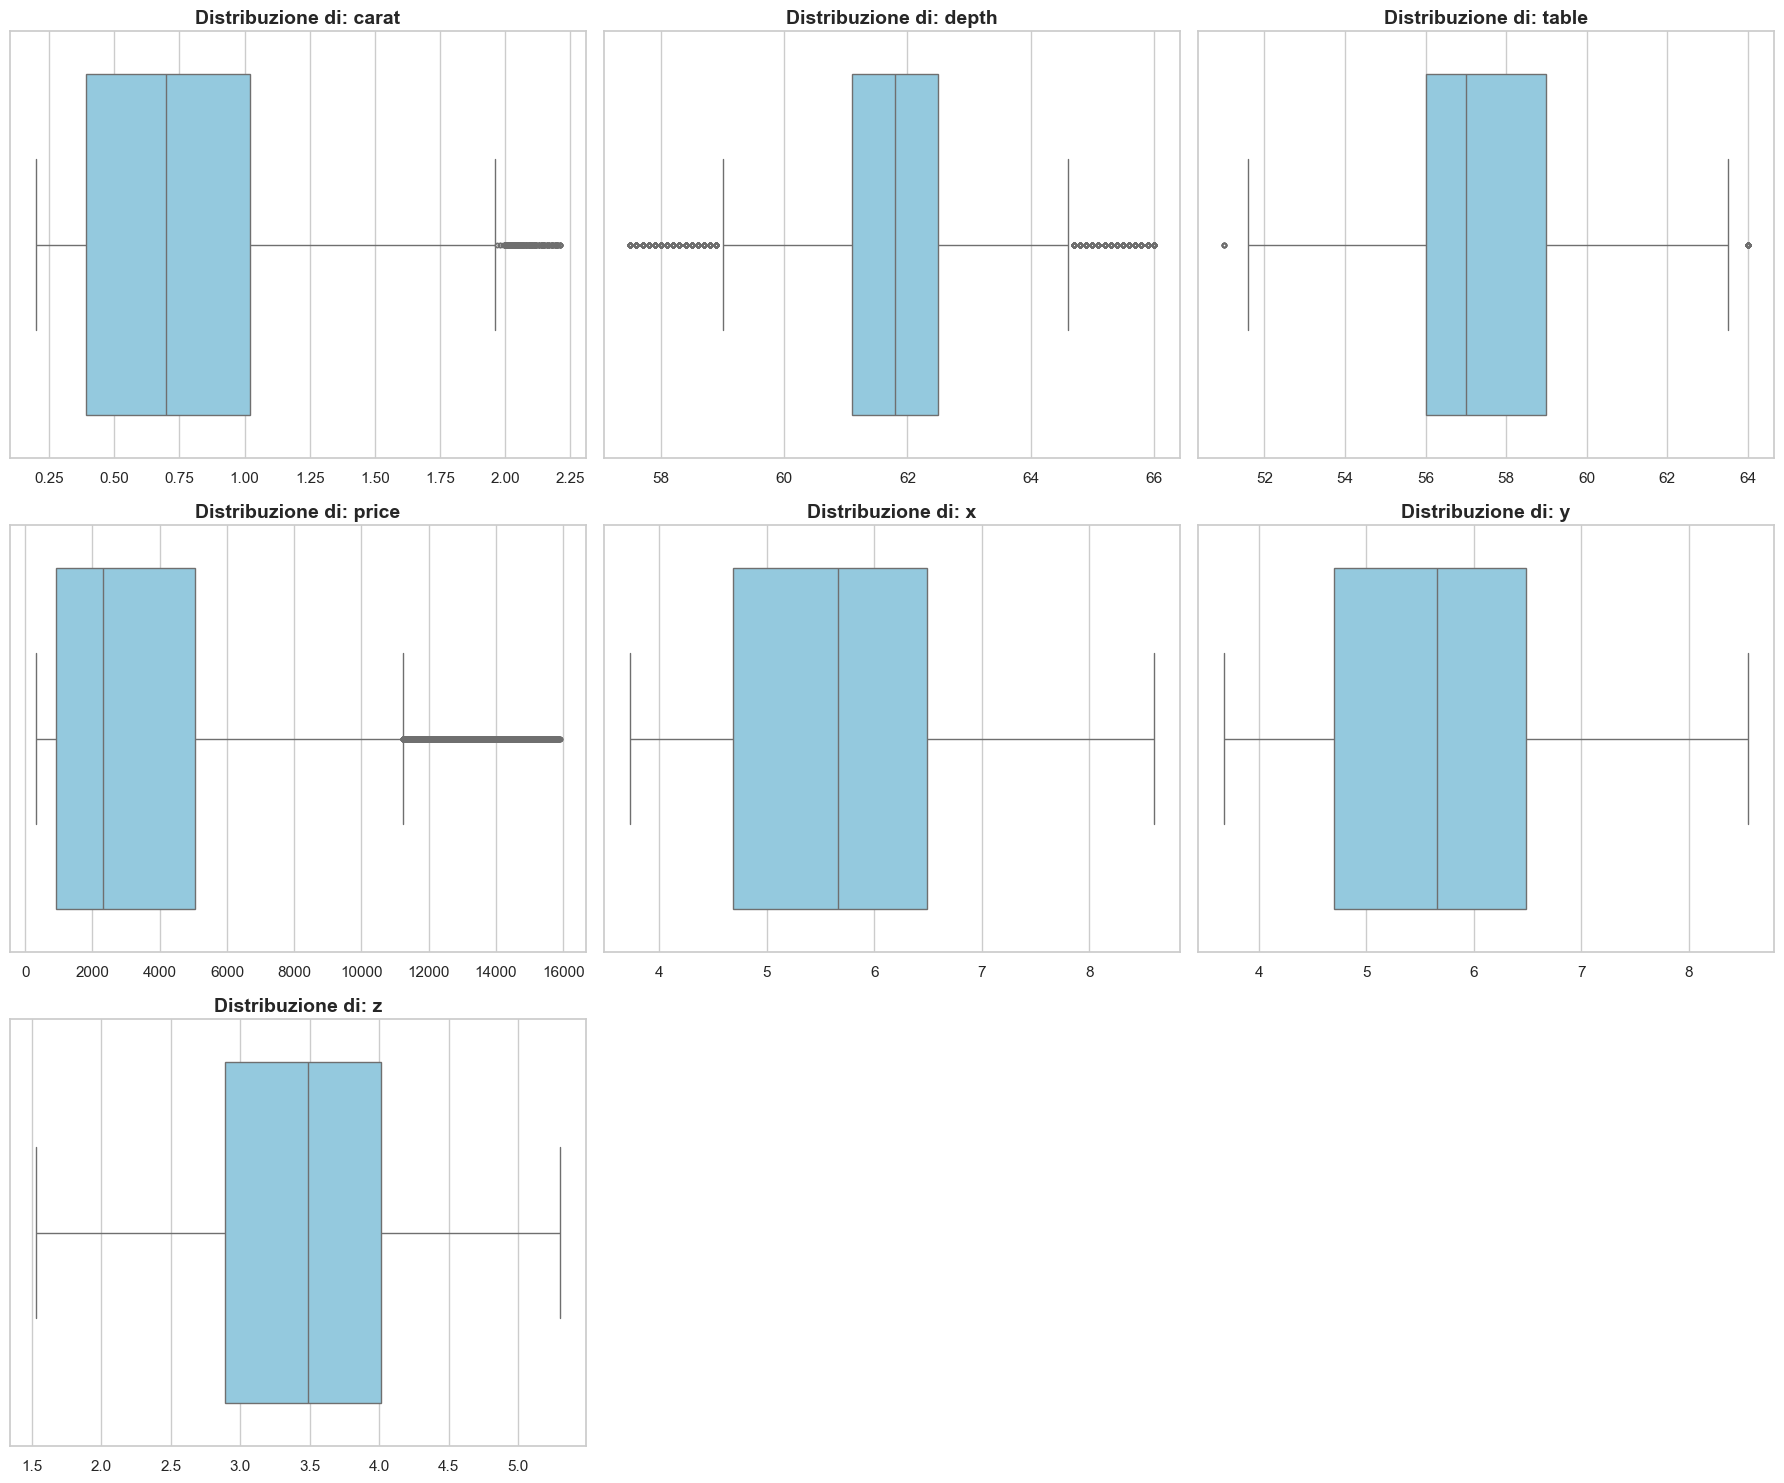

In [11]:
import matplotlib.pyplot as plt
# Impostiamo lo stile e la griglia

sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

In [14]:
# Creo feature volume
diamonds['volume'] = diamonds['x'] * diamonds['y'] * diamonds['z']

import pandas as pd

# Variabili categoriche da trasformare
categorical_cols = ['color', 'cut', 'clarity']

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


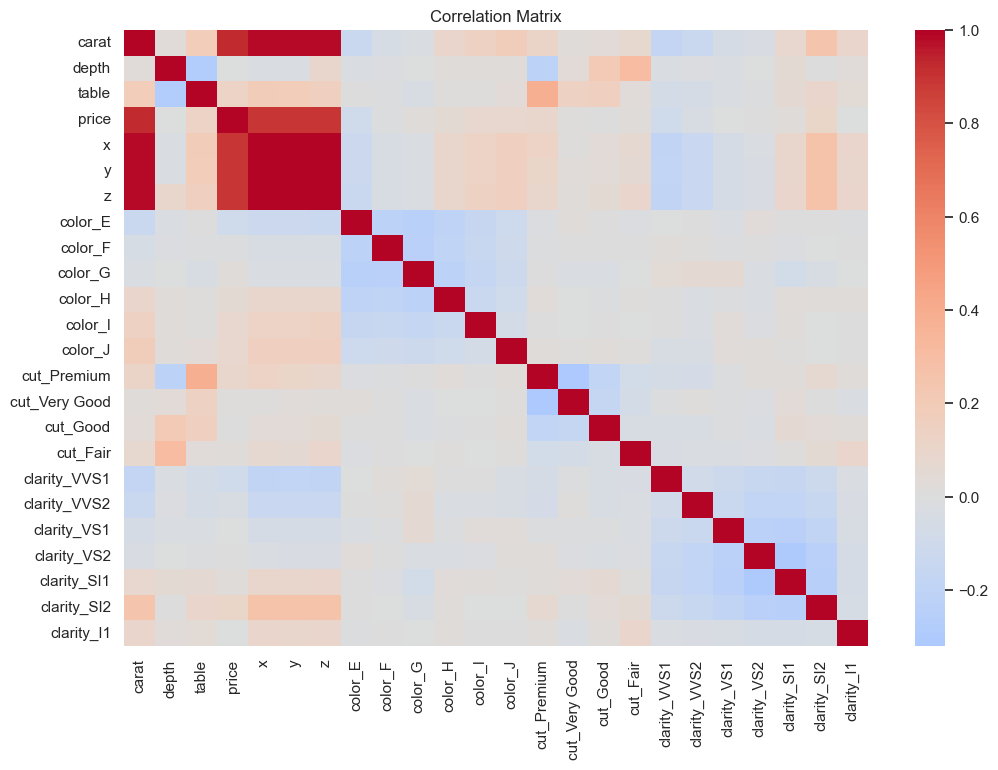

In [15]:
plt.figure(figsize=(12, 8))

# Solo colonne numeriche
corr = df_encoded.corr()

sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

In [ ]:


from sklearn.preprocessing import StandardScaler

num_cols = ['age', 'fare_log', 'sibsp', 'parch', 'family_size']


scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [1]:
pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 3.6 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.4 MB/s  0:00:00

   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
